In [ ]:
!sudo pip install deslib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.6/172.6 kB 2.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from deslib.dcs.ola import OLA

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving data_private_forModel.xlsx to data_private_forModel.xlsx


In [ ]:
# Sau khi tải lên, bạn có thể đọc file Excel như sau:
import pandas as pd
df = pd.read_excel('data_private_forModel.xlsx')
df.head()

,ChamNoi,CungNhac,CoLap,HanhViLapLai,KyNangGiaoTiepSom,ChoiLuanPhien,PhanUngTenGoi,DiNhonChan,ChiTro,TiepXucMat,TargetBinary
0,0,0,0,0,0.0,0.0,0.0,0,0.5,0.0,1
1,0,0,0,0,0.0,0.0,0.0,0,0.0,0.0,1
2,0,0,0,1,0.5,0.0,0.0,0,1.0,0.5,1
3,1,0,0,0,0.5,0.0,0.0,0,1.0,0.0,1
4,0,0,0,0,0.0,0.0,0.0,0,0.0,0.5,1


In [ ]:
for i, col in enumerate(df.columns):
    print(f"Vị trí {i}: {col}")

Vị trí 0: ChamNoi
Vị trí 1: CungNhac
Vị trí 2: CoLap
Vị trí 3: HanhViLapLai
Vị trí 4: KyNangGiaoTiepSom
Vị trí 5: ChoiLuanPhien
Vị trí 6: PhanUngTenGoi
Vị trí 7: DiNhonChan
Vị trí 8: ChiTro
Vị trí 9: TiepXucMat
Vị trí 10: TargetBinary


In [ ]:
# Liệt kê tên các cột
print(df.columns.tolist())
rows, cols = df.shape
print(f"Số hàng: {rows}, Số cột: {cols}")

['ChamNoi', 'CungNhac', 'CoLap', 'HanhViLapLai', 'KyNangGiaoTiepSom', 'ChoiLuanPhien', 'PhanUngTenGoi', 'DiNhonChan', 'ChiTro', 'TiepXucMat', 'TargetBinary']
Số hàng: 864, Số cột: 11


In [ ]:
X = df.iloc[:, 0:10]      # lấy từ cột 0 đến 13 (14 đặc trưng)
y = df.iloc[:, 10]        # lấy cột TargetBinary (vị trí 14)

# TRAINING VÀ ĐÁNH GIÁ MODEL

# CẢI TIẾN OLA

### PCA + OLA + kiểm soát đặc trưng --> Chọn Model này với 10 features sau

In [ ]:
# Liệt kê tên các cột
print(df.columns.tolist())

['ChamNoi', 'CungNhac', 'CoLap', 'HanhViLapLai', 'KyNangGiaoTiepSom', 'ChoiLuanPhien', 'PhanUngTenGoi', 'DiNhonChan', 'ChiTro', 'TiepXucMat', 'TargetBinary']


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.6 MB/s eta 0:00:00


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from deslib.dcs import OLA

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score

# === 1. Tách dữ liệu từ df_private gốc === 111111111111111
X = df.drop(columns='TargetBinary')
y = df['TargetBinary']
feature_names = X.columns.tolist()
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# === 2. Chuẩn hóa + PCA === 111111111
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# === 3. ColumnDropper hỗ trợ DataFrame và ndarray ===
class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, columns, feature_names=None):
        self.columns = columns
        self.feature_names = feature_names

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X.drop(columns=self.columns, errors='ignore')
        elif isinstance(X, np.ndarray):
            if self.feature_names is None or X.shape[1] != len(self.feature_names):
                raise ValueError("ColumnDropper: mismatch or missing feature names.")
            df = pd.DataFrame(X, columns=self.feature_names)
            return df.drop(columns=self.columns, errors='ignore').values
        else:
            raise ValueError("Unsupported input type for ColumnDropper.")

# === 4. Tạo pool model ===
pool_classifiers = []

# Group 1: mô hình PCA (Cập nhật với RandomForest, CatBoost, XGB) == 22222222
pca_models = [
    RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    CatBoostClassifier(depth=5, verbose=0, random_state=42),
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0, random_state=42)
]
for model in pca_models:
    model.fit(X_train_pca, y_train)
    pool_classifiers.append(model)

# Group 2: model loại bỏ TiepXucMat
dropper = ColumnDropper(columns=['TiepXucMat'], feature_names=feature_names)
reduced_pipe = Pipeline([
    ('drop', dropper),
    ('imputer', SimpleImputer()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])
reduced_pipe.fit(X_train_raw, y_train)
pool_classifiers.append(reduced_pipe)

# Group 3: model full raw
full_pipe = Pipeline([
    ('imputer', SimpleImputer()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])
full_pipe.fit(X_train_raw, y_train)
pool_classifiers.append(full_pipe)

# === 5. Huấn luyện OLA chỉ với mô hình PCA === 333333333333333
ola_pool = [clf for clf in pool_classifiers if not isinstance(clf, Pipeline)]
ola = OLA(pool_classifiers=ola_pool)
ola.fit(X_train_pca, y_train)

# === 6. Dự đoán OLA ===
y_pred = ola.predict(X_test_pca)

# === 7. Tính xác suất dự đoán ensemble
proba_list = []
for clf in pool_classifiers:
    try:
        if isinstance(clf, Pipeline):
            proba = clf.predict_proba(X_test_raw)[:, 1]
        else:
            proba = clf.predict_proba(X_test_pca)[:, 1]
        proba_list.append(proba)
    except Exception as e:
        print(f"[WARN] Bỏ qua model do lỗi: {e}")

y_prob = np.mean(proba_list, axis=0)

# === 8. Đánh giá
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) else 0
gmean = geometric_mean_score(y_test, y_pred)

# === 9. In kết quả
results = {
    "Accuracy": round(accuracy, 3),
    "Recall": round(recall, 3),
    "Precision": round(precision, 3),
    "F1-score": round(f1, 3),
    "ROC AUC": round(roc_auc, 3),
    "Specificity": round(specificity, 3),
    "G-Mean": round(gmean, 3)
}

print("=== Kết quả PCA + OLA với kiểm soát TiepXucMat ===")
for k, v in results.items():
    print(f"{k:12}: {v}")

=== Kết quả PCA + OLA với kiểm soát TiepXucMat ===
Accuracy    : 0.977
Recall      : 0.969
Precision   : 0.99
F1-score    : 0.979
ROC AUC     : 0.991
Specificity : 0.987
G-Mean      : 0.978


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



== Độ ảnh hưởng tổng hợp của các cột gốc trong PCA:
CoLap                2.545422
ChoiLuanPhien        2.510236
KyNangGiaoTiepSom    2.415590
CungNhac             2.404217
ChiTro               2.392919
HanhViLapLai         2.319694
ChamNoi              2.164961
PhanUngTenGoi        2.034019
DiNhonChan           1.896599
TiepXucMat           1.622900
dtype: float64


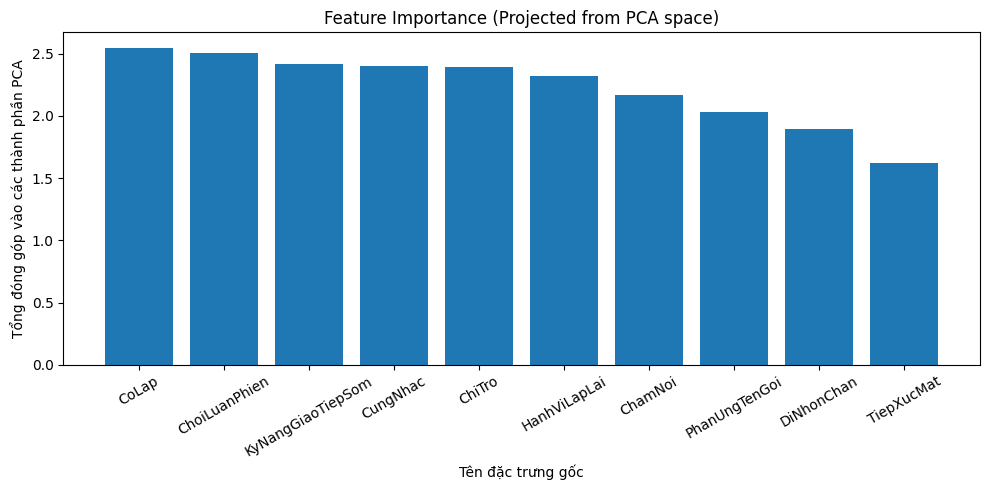

In [ ]:
# Lấy thành phần PCA
pca_components = pd.DataFrame(
    np.abs(pca.components_),
    columns=feature_names
)

# Tính tổng độ đóng góp của mỗi cột gốc vào tất cả các thành phần chính
pca_feature_influence = pca_components.sum(axis=0).sort_values(ascending=False)

print("\n== Độ ảnh hưởng tổng hợp của các cột gốc trong PCA:")
print(pca_feature_influence)

# Lấy thành phần PCA
pca_components = pd.DataFrame(
    np.abs(pca.components_),
    columns=feature_names
)

# Tính tổng độ đóng góp của mỗi đặc trưng gốc
pca_feature_influence = pca_components.sum(axis=0).sort_values(ascending=False)

# Trực quan hóa
names = pca_feature_influence.index.tolist()
scores = pca_feature_influence.values.tolist()

plt.figure(figsize=(10, 5))
plt.bar(names, scores)
plt.xticks(rotation=30)
plt.title('Feature Importance (Projected from PCA space)')
plt.xlabel('Tên đặc trưng gốc')
plt.ylabel('Tổng đóng góp vào các thành phần PCA')
plt.tight_layout()
plt.show()



In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from deslib.dcs import OLA

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score

# === 1. Tách dữ liệu từ df_private gốc ===
X = df.drop(columns='TargetBinary')
y = df['TargetBinary']
feature_names = X.columns.tolist()

# Khởi tạo StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

# === 2. Vòng lặp Cross-validation ===
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
    X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Chuẩn hóa + PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    pca = PCA(n_components=0.95, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # === 3. ColumnDropper hỗ trợ DataFrame và ndarray ===
    class ColumnDropper(BaseEstimator, TransformerMixin):
        def __init__(self, columns, feature_names=None):
            self.columns = columns
            self.feature_names = feature_names

        def fit(self, X, y=None):
            return self

        def transform(self, X):
            if isinstance(X, pd.DataFrame):
                return X.drop(columns=self.columns, errors='ignore')
            elif isinstance(X, np.ndarray):
                if self.feature_names is None or X.shape[1] != len(self.feature_names):
                    raise ValueError("ColumnDropper: mismatch or missing feature names.")
                df = pd.DataFrame(X, columns=self.feature_names)
                return df.drop(columns=self.columns, errors='ignore').values
            else:
                raise ValueError("Unsupported input type for ColumnDropper.")

    # === 4. Tạo pool model ===
    pool_classifiers = []

    # Group 1: mô hình PCA
    pca_models = [
        RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
        CatBoostClassifier(depth=5, verbose=0, random_state=42),
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0, random_state=42)
    ]
    for model in pca_models:
        model.fit(X_train_pca, y_train)
        pool_classifiers.append(model)

    # Group 2: model loại bỏ TiepXucMat
    dropper = ColumnDropper(columns=['TiepXucMat'], feature_names=feature_names)
    reduced_pipe = Pipeline([
        ('drop', dropper),
        ('imputer', SimpleImputer()),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    reduced_pipe.fit(X_train_raw, y_train)
    pool_classifiers.append(reduced_pipe)

    # Group 3: model full raw
    full_pipe = Pipeline([
        ('imputer', SimpleImputer()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ])
    full_pipe.fit(X_train_raw, y_train)
    pool_classifiers.append(full_pipe)

    # === 5. Huấn luyện OLA chỉ với mô hình PCA ===
    ola_pool = [clf for clf in pool_classifiers if not isinstance(clf, Pipeline)]
    ola = OLA(pool_classifiers=ola_pool)
    ola.fit(X_train_pca, y_train)

    # === 6. Dự đoán OLA ===
    y_pred = ola.predict(X_test_pca)

    # === 7. Tính xác suất dự đoán ensemble
    proba_list = []
    for clf in pool_classifiers:
        try:
            if isinstance(clf, Pipeline):
                proba = clf.predict_proba(X_test_raw)[:, 1]
            else:
                proba = clf.predict_proba(X_test_pca)[:, 1]
            proba_list.append(proba)
        except Exception as e:
            print(f"[WARN] Bỏ qua model do lỗi: {e}")

    y_prob = np.mean(proba_list, axis=0)

    # === 8. Đánh giá
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0
    gmean = geometric_mean_score(y_test, y_pred)

    metrics = {
        "Fold": fold,
        "Accuracy": accuracy,
        "Recall": recall,
        "Precision": precision,
        "F1-score": f1,
        "ROC AUC": roc_auc,
        "Specificity": specificity,
        "G-Mean": gmean
    }
    cv_results.append(metrics)

# === 9. Hiển thị kết quả sau khi hoàn tất tất cả folds ===
df_cv_results = pd.DataFrame(cv_results)

# Tính dòng trung bình
average_row = df_cv_results.mean(numeric_only=True)
average_row['Fold'] = 'Trung bình'

# Ghép vào DataFrame kết quả
df_cv_results = pd.concat([df_cv_results, pd.DataFrame([average_row])], ignore_index=True)

# Làm tròn hiển thị
df_cv_results = df_cv_results.round(3)
print("==== Kết quả Cross-Validation cho PCA + OLA + kiểm soát TiepXucMat ====")
print(df_cv_results.to_string(index=False))


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator.

==== Kết quả Cross-Validation cho PCA + OLA + kiểm soát TiepXucMat ====
      Fold  Accuracy  Recall  Precision  F1-score  ROC AUC  Specificity  G-Mean
         1     0.971   0.969      0.979     0.974    0.994        0.973   0.971
         2     0.977   0.980      0.980     0.980    0.999        0.973   0.976
         3     0.971   0.969      0.979     0.974    0.994        0.973   0.971
         4     0.983   0.980      0.990     0.985    0.999        0.987   0.983
         5     0.971   0.948      1.000     0.974    0.993        1.000   0.974
Trung bình     0.975   0.969      0.986     0.977    0.996        0.981   0.975


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/tmp/ipython-input-19-2606175139.py:146: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Trung bình' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  average_row['Fold'] = 'Trung bình'
